In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [20]:
'''PRÉ DEFINIÇÕES INICIAIS PARA ORGANIZAÇÃO DOS DADOS'''

# Arquivo de 2025 para base de aprendizado
df_treino = pd.read_csv("INMET_S_PR_A807_CURITIBA_01-01-2025_A_31-12-2025.CSV", # Lê o arquivo CSV
                        sep=';', # define o ponto e vírgula como separador de colunas
                        encoding='latin-1', # resolve problemas de acentuação comuns em arquivos brasileiros
                        skiprows=8, # pula as linhas iniciais do cabeçalho administrativo
                        decimal=',') # converte números como "15,5" para 15.5 (float)

# Arquivo de 2026 para validar o modelo depois
df_teste = pd.read_csv("INMET_S_PR_A807_CURITIBA_01-01-2026_A_28-02-2026.CSV", sep=';', encoding='latin-1', skiprows=8, decimal=',')

# Exibir colunas e primeiras linhas
display(df_treino.head())

,Data,Hora UTC,"PRECIPITAÇÃO TOTAL, HORÁRIO (mm)","PRESSAO ATMOSFERICA AO NIVEL DA ESTACAO, HORARIA (mB)",PRESSÃO ATMOSFERICA MAX.NA HORA ANT. (AUT) (mB),PRESSÃO ATMOSFERICA MIN. NA HORA ANT. (AUT) (mB),RADIACAO GLOBAL (Kj/m²),"TEMPERATURA DO AR - BULBO SECO, HORARIA (°C)",TEMPERATURA DO PONTO DE ORVALHO (°C),TEMPERATURA MÁXIMA NA HORA ANT. (AUT) (°C),TEMPERATURA MÍNIMA NA HORA ANT. (AUT) (°C),TEMPERATURA ORVALHO MAX. NA HORA ANT. (AUT) (°C),TEMPERATURA ORVALHO MIN. NA HORA ANT. (AUT) (°C),UMIDADE REL. MAX. NA HORA ANT. (AUT) (%),UMIDADE REL. MIN. NA HORA ANT. (AUT) (%),"UMIDADE RELATIVA DO AR, HORARIA (%)","VENTO, DIREÇÃO HORARIA (gr) (° (gr))","VENTO, RAJADA MAXIMA (m/s)","VENTO, VELOCIDADE HORARIA (m/s)",Unnamed: 19
0,2025/01/01,0000 UTC,0.0,911.1,911.1,910.2,NaN,20.3,18.3,20.4,20.2,18.6,18.1,90.0,88.0,89.0,77.0,5.2,2.0,NaN
1,2025/01/01,0100 UTC,0.0,911.7,911.8,911.1,NaN,20.0,18.1,20.4,20.0,18.6,17.9,89.0,88.0,89.0,84.0,5.5,3.0,NaN
2,2025/01/01,0200 UTC,0.0,911.4,911.7,911.3,NaN,19.7,18.1,20.0,19.6,18.3,18.0,91.0,89.0,90.0,92.0,6.0,2.4,NaN
3,2025/01/01,0300 UTC,0.0,911.3,911.4,911.2,NaN,19.7,18.0,19.8,19.7,18.2,17.9,91.0,90.0,90.0,78.0,5.8,2.7,NaN
4,2025/01/01,0400 UTC,0.0,911.0,911.3,911.0,NaN,19.4,18.0,19.7,19.4,18.1,17.9,92.0,90.0,92.0,77.0,6.3,2.3,NaN


In [21]:
# Substitui o valor de erro (-9999) por "NaN" nos dois DataFrames
df_treino = df_treino.replace(-9999, np.nan)
df_teste = df_teste.replace(-9999, np.nan)

#Separar apenas as colunas importantes para analisar a temperatura
col_umid = 'UMIDADE RELATIVA DO AR, HORARIA (%)'
col_pres = 'PRESSAO ATMOSFERICA AO NIVEL DA ESTACAO, HORARIA (mB)'
col_rad  = 'RADIACAO GLOBAL (Kj/m²)'

features = [col_umid, col_pres, col_rad]

#Variável alvo original
col_temp = 'TEMPERATURA DO AR - BULBO SECO, HORARIA (°C)'

# Verificação de segurança
print(f"Total de registros para treino: {len(df_treino)}") #quantidade antes de limpar linhas vazias
print(f"Total de registros para teste: {len(df_teste)}")

Total de registros para treino: 8760
Total de registros para teste: 1416


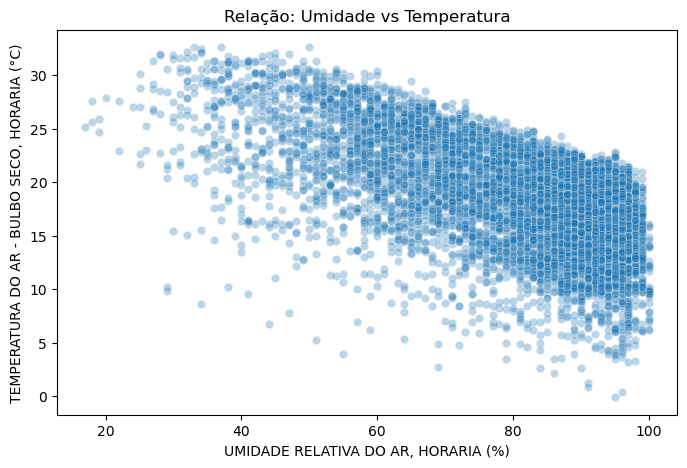

In [22]:
# Gráfico de Dispersão: Umidade vs Temperatura
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df_treino, x='UMIDADE RELATIVA DO AR, HORARIA (%)', y=col_temp, alpha=0.3)
plt.title('Relação: Umidade vs Temperatura')
plt.show()

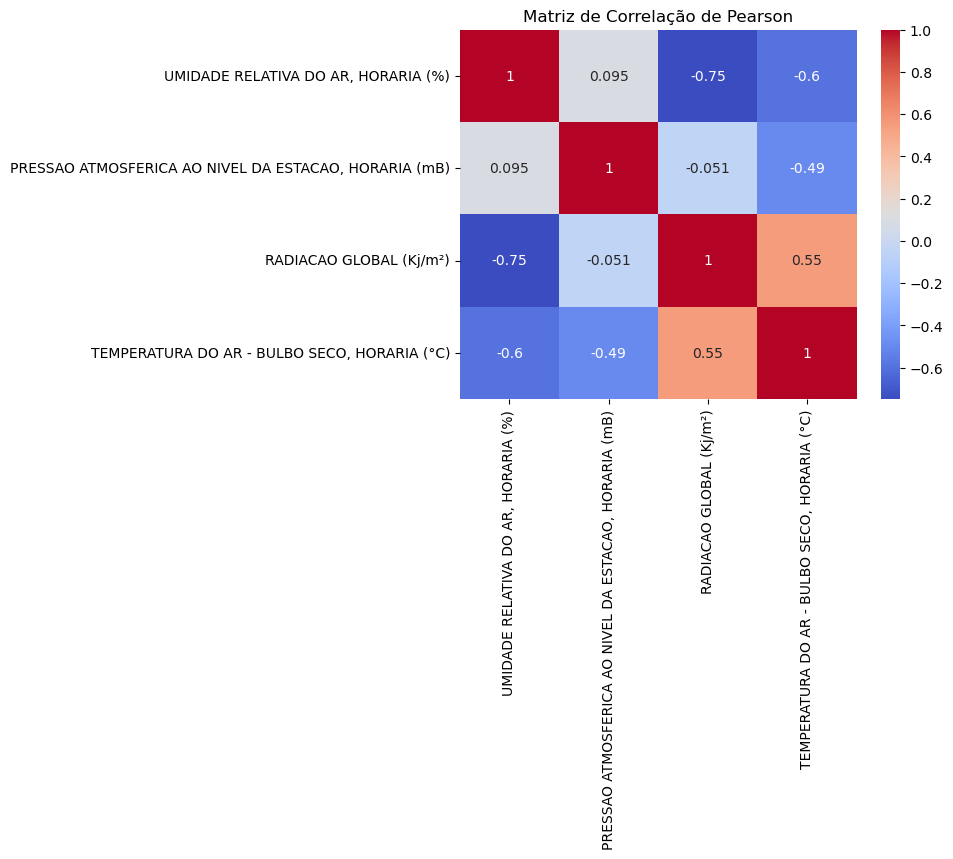

In [23]:
# Matriz de Correlação Numérica
corr = df_treino[features + [col_temp]].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Matriz de Correlação de Pearson')
plt.show()

In [24]:
# Limpando nulos e separando Treino (2025) e Teste (2026)
df_treino_reg = df_treino[features + [col_temp]].dropna()
df_teste_reg = df_teste[features + [col_temp]].dropna()

X_train = df_treino_reg[features]
y_train = df_treino_reg[col_temp]

X_test = df_teste_reg[features]
y_test = df_teste_reg[col_temp]

# Padronização (Essencial para Regressão Linear e SVR)
scaler_reg = StandardScaler()
X_train_scaled = scaler_reg.fit_transform(X_train)
X_test_scaled = scaler_reg.transform(X_test)

print(f"Total de registros para treino: {len(X_train)}") #quantidade após limpar linhas vazias
print(f"Total de registros para teste: {len(X_test)}")

Total de registros para treino: 4930
Total de registros para teste: 936


Treinando os 4 Modelos de Regressão

In [30]:
# Regressão Linear
modelo_linear = LinearRegression()
modelo_linear.fit(X_train_scaled, y_train)

# Árvore de Decisão para Regressão
modelo_arvore_reg = DecisionTreeRegressor(max_depth=5, random_state=42)
modelo_arvore_reg.fit(X_train_scaled, y_train)

# Random Forest Regressor
modelo_rf_reg = RandomForestRegressor(n_estimators=100, random_state=42)
modelo_rf_reg.fit(X_train_scaled, y_train)

# SVR
modelo_svr = SVR(kernel='rbf')
modelo_svr.fit(X_train_scaled, y_train)

print('Modelos treinados')

Modelos treinados


                    MAE       MSE      RMSE        R2
Regr. Linear   2.016007  6.298955  2.509772  0.535977
Árvore         1.913347  5.686417  2.384621  0.581101
Random Forest  2.042325  6.544256  2.558174  0.517907
SVR            1.781701  4.929027  2.220141  0.636895


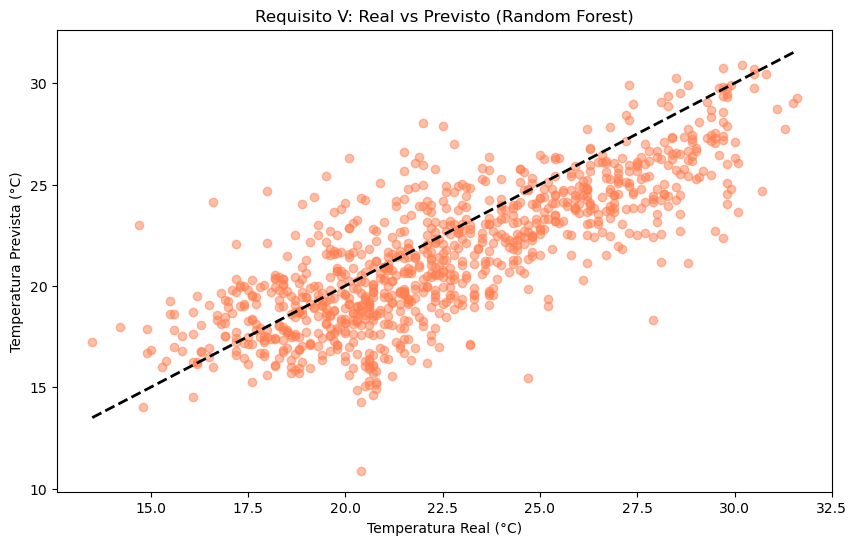

In [31]:
# Criando uma função para facilitar a coleta de métricas
def avaliar_regressao(modelo, X_teste, y_teste):
    preditos = modelo.predict(X_teste)
    mae = mean_absolute_error(y_teste, preditos)
    mse = mean_squared_error(y_teste, preditos)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_teste, preditos)
    return [mae, mse, rmse, r2]

# Coletando resultados de todos os modelos
resultados_reg = {
    'Regr. Linear': avaliar_regressao(modelo_linear, X_test_scaled, y_test),
    'Árvore': avaliar_regressao(modelo_arvore_reg, X_test_scaled, y_test),
    'Random Forest': avaliar_regressao(modelo_rf_reg, X_test_scaled, y_test),
    'SVR': avaliar_regressao(modelo_svr, X_test_scaled, y_test)
}

# Transformando em DataFrame para o relatório
df_metricas = pd.DataFrame(resultados_reg, index=['MAE', 'MSE', 'RMSE', 'R2']).T
print(df_metricas)

# Visualização: Real vs Previsto (Usando o Random Forest como exemplo)
previsoes_finais = modelo_rf_reg.predict(X_test_scaled)
plt.figure(figsize=(10, 6))
plt.scatter(y_test, previsoes_finais, alpha=0.5, color='coral')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--k', lw=2)
plt.xlabel('Temperatura Real (°C)')
plt.ylabel('Temperatura Prevista (°C)')
plt.title('Requisito V: Real vs Previsto (Random Forest)')
plt.show()


In [35]:
def prever_temperatura_sistema():
    print("--- Sistema de Previsão de Temperatura (Regressão) ---")
    umid = float(input("Digite a Umidade (%): "))
    pres = float(input("Digite a Pressão (mB): "))
    radi = float(input("Digite a Radiação (Kj/m²): "))
    
    # Prepara os dados
    entrada = np.array([[umid, pres, radi]])
    entrada_scaled = scaler_reg.transform(entrada)
    
    # Previsão
    temp_prevista = modelo_rf_reg.predict(entrada_scaled)

    print("Umidade ", umid)
    print("Pressão  ", pres)
    print("Radiação  ", radi)
    
    print(f"\nPrevisão temperatura: {temp_prevista[0]:.1f}°C")

# Para testar:
prever_temperatura_sistema()

--- Sistema de Previsão de Temperatura (Regressão) ---
Umidade  85.0
Pressão   1005.0
Radiação   400.0

Previsão temperatura: 11.1°C


c:\Users\desyr\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
